In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import date

import analysis_utils
import isku_utils
import plotting_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
# Baseline period for Impact
BASELINE_PERIOD = slice("1996-01-01", "2025-12-31")
# Define Forecast Months
FC_MONTHS = [9, 10, 11, 12, 1, 2]
FC_PERIOD = slice("2026-09-01", "2027-02-28")

config = analysis_utils.ImpactConfig( version = "v260915",
                                     baseline_period=BASELINE_PERIOD, 
                                     polygons_path= os.environ["POREALLAS_REGIONS_POLYGONS_URI"],
                                     socioeconomics_path= os.environ["POREALLAS_SOCIOECONOMICS_URI"],
                                     rate=False, 
                                     months = FC_MONTHS,
                                     hotonly = "hotonly", 
                                     dims = ['number', 'sample'])


In [3]:
# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_PARSED_FORECAST_URI"]

s51 = xr.open_zarr(TAS_FORECAST_RAW)
forecast = s51.sel(time=FC_PERIOD).groupby("time.month").mean()-273.15
forecast_ir = isku_utils.grid_to_ir(forecast.compute(), savefile=None)

forecast_ds = forecast_ir.assign(
    forecast_mean=forecast_ir['tas'].mean(dim=['number']),
    forecast_std=forecast_ir['tas'].std(dim=['number'])
)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [4]:
def merge_regions(ds, socioec_ds, forecast_ds):
    if isinstance(ds, xr.DataTree):
        ds = ds.to_dataset()
    merged = xr.merge([
        ds,
        socioec_ds[['pop']],
        forecast_ds[['forecast_mean', 'forecast_std']]
    ], join='inner')

    return merged

def filter_regions(merged, min_population, min_dist_from_mmt, max_dist_from_mmt):
    """
     select regions where population >= min_population and
    |forecast_mean - mmt| <= max_dist_from_mmt.

    mmt in ds has dims (sample, age_cohort, region) — collapsed across sample/age_cohort
    (mean) to get a single per-region MMT for the distance filter.
    """
    mmt_per_region = merged['mmt'].mean(dim=['sample', 'age_cohort'])
    dist_from_mmt = np.abs(merged['forecast_mean'] - mmt_per_region)

    region_mask = (merged['pop'] >= min_population) & (dist_from_mmt <= max_dist_from_mmt)& (dist_from_mmt >= min_dist_from_mmt)
    selected_regions = merged['region'].values[region_mask.values]

    return merged.sel(region=selected_regions)

In [5]:
EFFECTS_URI = "/home/emily_zuetell/projects/poreallas/data/v20260909_effects_with_betas.zarr"
effect = xr.open_datatree(EFFECTS_URI, consolidated=False)

# Compute impact: forecast - baseline
impact = analysis_utils.compute_impact(
    effect.chunk({dim: -1 for dim in config.dims}),
    config,
    ensemble=True,
)
# Use only the defined 6-months
impact = impact.sel(month=config.months)

In [6]:
# Load Betas
# September Projection - No Adaptation
ds1 = effect['/fixed_beta']
ds1 = merge_regions(ds1, config.socioeconomics, forecast_ds).compute()
# Filter regions w/ 0 pop
ds1 = ds1.where(ds1['pop'] > 1, drop=True)

In [64]:
da = ds1.sel(age_cohort = 'age65plus')
mask = da['mmt'].isin([29.5, 10.5]).any(dim="sample")
check = da.isel(region=mask.values)

Regions with MMT errors have higher GDP than the full distribution

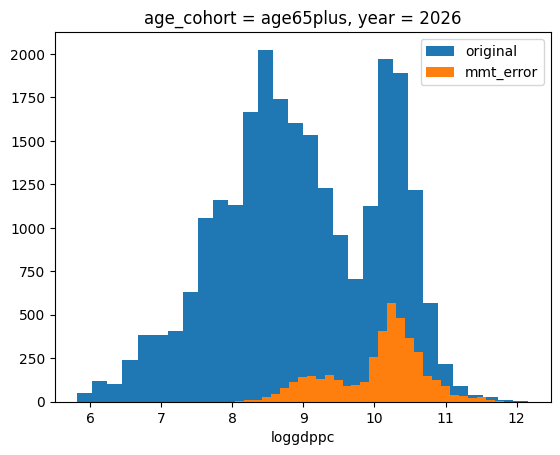

In [15]:
fig, ax = plt.subplots()
ds1['loggdppc'].plot.hist(bins = 30, ax = ax, label = 'original')
check['loggdppc'].plot.hist(bins = 30, ax = ax, label = 'mmt_error')
plt.legend()


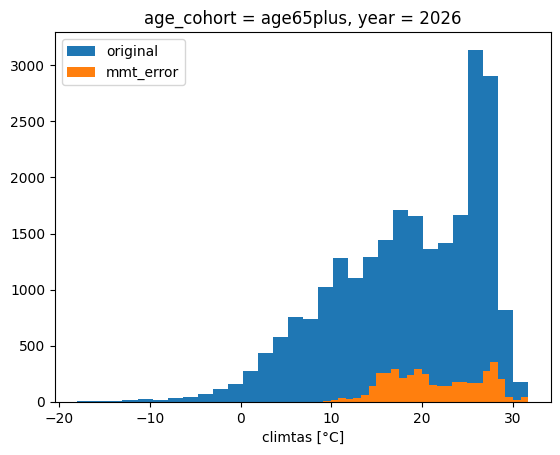

In [16]:
fig, ax = plt.subplots()
ds1['climtas'].plot.hist(bins = 30, ax = ax, label = 'original')
check['climtas'].plot.hist(bins = 30, ax = ax, label = 'mmt_error')
plt.legend()

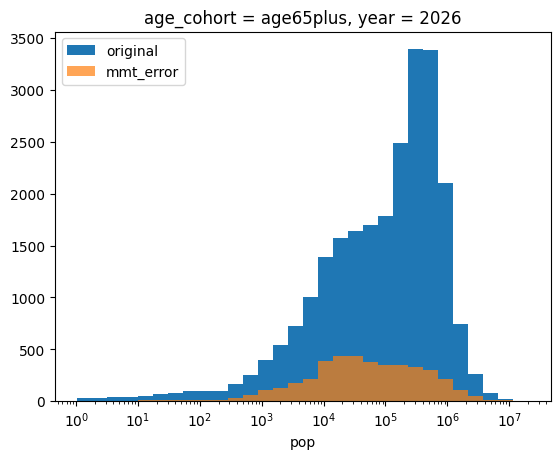

In [19]:
lo = float(ds1['pop'].where(ds1['pop'] > 0).min())
hi = float(ds1['pop'].max())
bins = np.logspace(np.log10(lo), np.log10(hi), 31)

fig, ax = plt.subplots()
ds1['pop'].plot.hist(bins=bins, ax=ax, label='original')
check['pop'].plot.hist(bins=bins, ax=ax, label='mmt_error', alpha=0.7)
ax.set_xscale('log')
ax.legend()

In [55]:
socioeconomics = xr.open_zarr(config.socioeconomics_path)

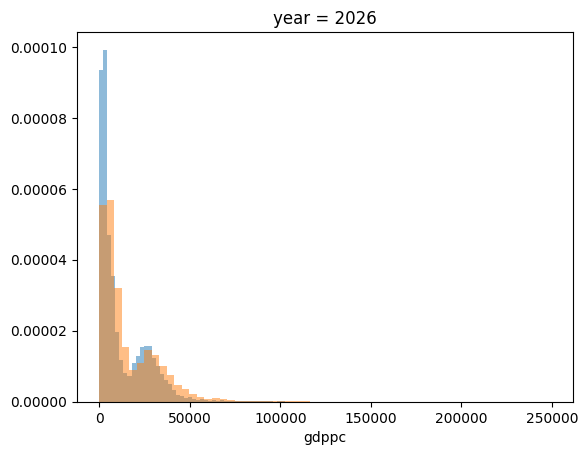

In [65]:
fig, ax = plt.subplots()
socioeconomics.sel(year = 2015)['gdppc'].plot.hist(bins = 60, alpha = .5, ax = ax, density = True)
socioeconomics.sel(year = 2026)['gdppc'].plot.hist(bins = 60, alpha = .5, ax = ax, density = True)

keep = mask['region'].values[mask.values]
check = impact.isel(region=impact['region'].isin(keep).values)

In [11]:
keep = mask['region'].values[mask.values]
check = impact.isel(region=impact['region'].isin(keep).values)

check.mean(dim = config.dims).sum().values

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


array(29703.52969697)

In [12]:
_polygons_check = analysis_utils.xarray_to_gpd(
    check.mean(dim = config.dims).sum(dim = 'month'), config.polygons
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


# Clipping Behavior

In [7]:
beta_noclip = xr.open_dataset("/home/emily_zuetell/projects/poreallas/data/beta_no_clip.zarr")
beta_noclip = merge_regions(beta_noclip, config.socioeconomics, forecast_ds).compute()

beta_clip_local = xr.open_dataset("/home/emily_zuetell/projects/poreallas/data/beta_clipped_localminima.zarr")
beta_clip_local = merge_regions(beta_clip_local, config.socioeconomics, forecast_ds).compute()

beta_clip_goodmoney = xr.open_dataset("/home/emily_zuetell/projects/poreallas/data/beta_clipped_goodmoney.zarr")
beta_clip_goodmoney = merge_regions(beta_clip_goodmoney, config.socioeconomics, forecast_ds).compute()

In [24]:
def minimum_arg(x: xr.DataArray, *, dim="tas_bin", lmmt=10.0, ummt=30.0):
    """
    Get minimum and its associated dim label within an inclusive range along dim
    """
    # Find minimum within inclusive range, get the dim label for the minimum's position.
    in_range = (x[dim] >= lmmt) & (x[dim] <= ummt)
    constrained_arg = x.where(in_range).argmin(dim=dim)
    mmt_temp = x[dim].isel({dim: constrained_arg})
    on_bound = (mmt_temp < 11) | (mmt_temp > 29)

    # Fallback: local minimum along tas_bin, per (dims = sample, age-cohort)
    is_local_min = (x < x.shift({dim: 1})) & (x < x.shift({dim: -1}))
    local_arg = x.where(is_local_min, np.inf).argmin(dim=dim)
    has_local_min = is_local_min.any(dim=dim)

    min_arg = xr.where(on_bound & has_local_min, local_arg, constrained_arg)
    min_value = x.isel({dim: min_arg})
    return min_value, min_arg

In [21]:
x = beta_noclip.sel(region = "ARE.1").sel(age_cohort = 'age65plus')['beta']

In [27]:
min_value, min_arg = minimum_arg(x)

In [28]:
min_value

<xarray.DataArray 'beta' (sample: 15)> Size: 60B
array([-0.17732155, -0.20313302, -0.13090459, -0.17150882, -5.5889697 ,
       -1.3317803 , -0.46004596, -1.3123548 , -0.41055992, -0.9881421 ,
       -0.01673973, -0.8594842 , -0.00575528, -1.1251848 , -2.7728984 ],
      dtype=float32)
Coordinates:
  * sample      (sample) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
    tas_bin     (sample) float64 120B -1.5 1.5 -1.5 1.5 ... 4.5 -0.5 5.5 -5.5
    age_cohort  StringDType() 16B 'age65plus'
    region      StringDType() 16B 'ARE.1'
    year        int64 8B 2026

(-10.0, 15.0)

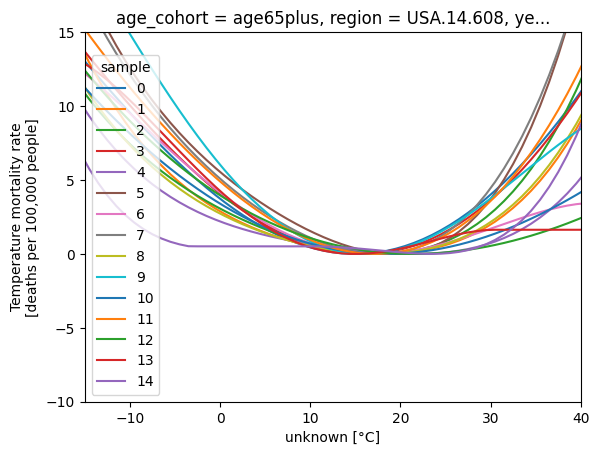

In [30]:
ds1.sel(region = 'USA.14.608').sel(age_cohort = 'age65plus')['beta'].plot.line(x = 'tas_bin')
plt.xlim(-15, 40)
plt.ylim(-10, 15)

In [31]:
ds1.sel(region = 'ARE.1').sel(age_cohort = 'age65plus')['mmt']

<xarray.DataArray 'mmt' (sample: 15)> Size: 60B
array([10.5, 10.5, 10.5, 10.5, 10.5, 29.5, 10.5, 29.5, 29.5, 10.5, 10.5,
       10.5, 29.5, 10.5, 10.5], dtype=float32)
Coordinates:
  * sample      (sample) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
    age_cohort  StringDType() 16B 'age65plus'
    region      StringDType() 16B 'ARE.1'
    year        int64 8B 2026
Attributes: (12/43)
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      64800
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    poreallas_sim_stop_year:                  2027
    poreallas_qdm_nquantiles:                 100
    poreallas_ref_uri:                        gs://poreallas-public-20260605/...
    poreallas_hist_uri:                       gs://poreallas-public-20260605/...
    poreallas_sim_uri:                        gs://poreallas-public-20260605/...
    units_metadata:                           temperature: unknown

(-10.0, 15.0)

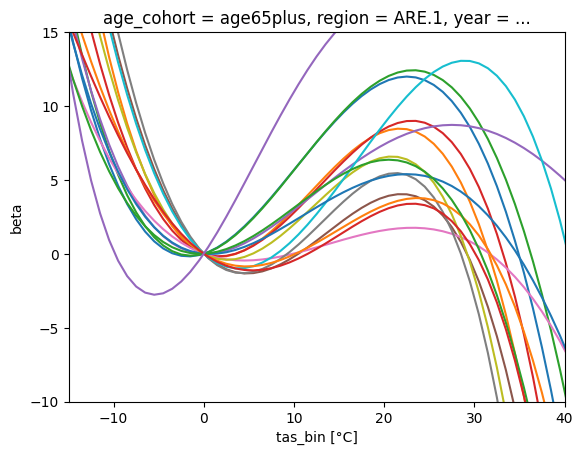

In [52]:
beta_noclip.sel(region = 'ARE.1').sel(age_cohort = 'age65plus')['beta'].plot.line(x = 'tas_bin', add_legend = False)
plt.xlim(-15, 40)
plt.ylim(-10, 15)

(-10.0, 15.0)

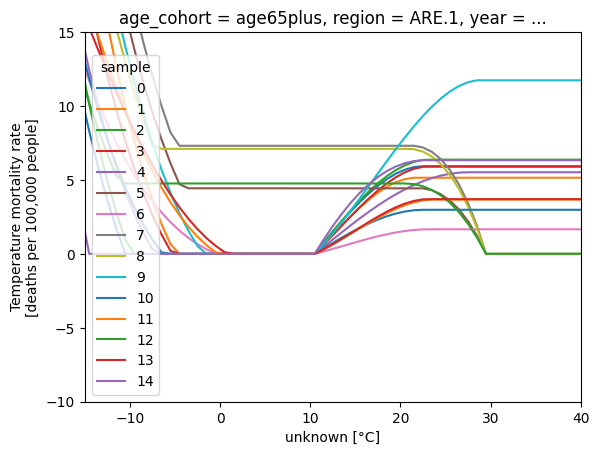

In [ ]:
ds1.sel(region = 'ARE.1').sel(age_cohort = 'age65plus')['beta'].plot.line(x = 'tas_bin')
plt.xlim(-15, 40)
plt.ylim(-10, 15)

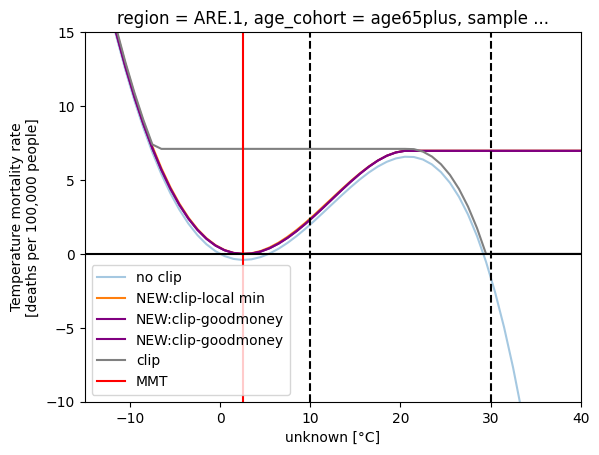

In [17]:
i = 8
region = 'ARE.1'
#region = 'USA.14.608'
beta_noclip.sel(region = region).sel(age_cohort = 'age65plus').sel(sample = i)['beta'].plot(label = 'no clip', alpha = 0.4)
beta_clip_local.sel(region = region).sel(age_cohort = 'age65plus').sel(sample = i)['beta'].plot(label = 'NEW:clip-local min')
beta_clip_goodmoney.sel(region = region).sel(year = 2025, age_cohort = 'age65plus').sel(sample = i)['beta'].plot(label = 'NEW:clip-goodmoney', color = 'purple')
beta_clip_goodmoney.sel(region = region).sel(year = 2015, age_cohort = 'age65plus').sel(sample = i)['beta'].plot(label = 'NEW:clip-goodmoney', color = 'purple')
ds1.sel(region = region).sel(age_cohort = 'age65plus').sel(sample = i)['beta'].plot(label = 'clip', color = 'gray')
plt.axvline(beta_clip_local.sel(region = region).sel(age_cohort = 'age65plus').sel(sample = i)['mmt'].values, color = 'red', label = 'MMT')
plt.axhline(0, color = 'k')
plt.axvline(10, color = 'k', linestyle = '--')
plt.axvline(30, color = 'k', linestyle = '--')
plt.xlim(-15, 40)
plt.ylim(-10, 15)
plt.legend()